### Import Libraries

In [392]:
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import *


### Load Dataset

In [393]:
df = pd.read_csv("C:/Users/ypyas/Desktop/Machine Learning Projects/Heart_Disease_Prediction/Data/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


### Basic Data Understanding

In [489]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [395]:
df.shape

(1025, 14)

In [396]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [397]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Data Quality Check

In [398]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [399]:
df.duplicated().sum()

np.int64(723)

In [400]:
df.drop_duplicates(inplace=True)

In [401]:
df.shape

(302, 14)

In [402]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

### Exploratory Data Analysis(EDA)

#### Target Variable Analysis

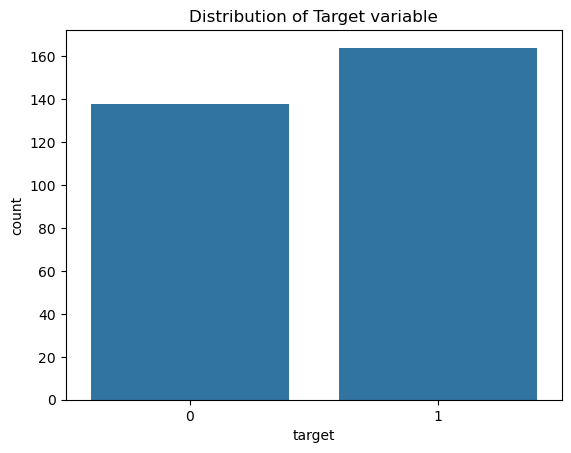

In [403]:
sns.countplot(x='target', data=df)
plt.title('Distribution of Target variable')
plt.show()

#### Observation 


In [404]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

#### Numerical Feature Analysis

In [405]:
columns = ['age','trestbps', 'chol', 'thalach', 'oldpeak']

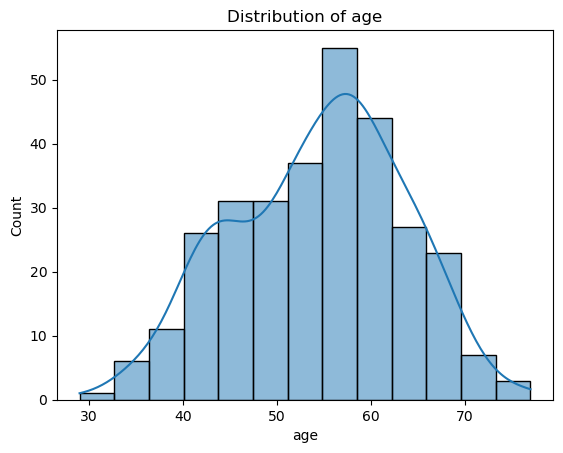

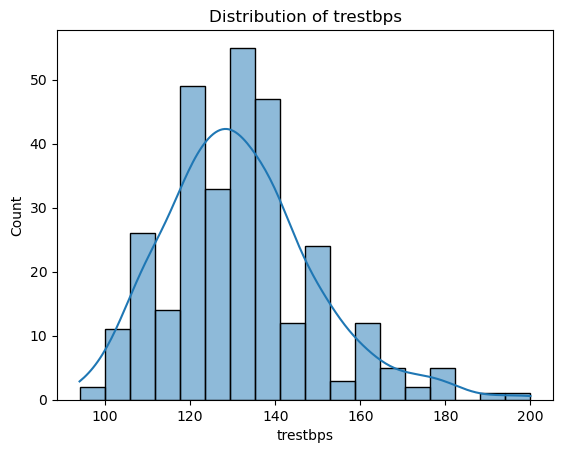

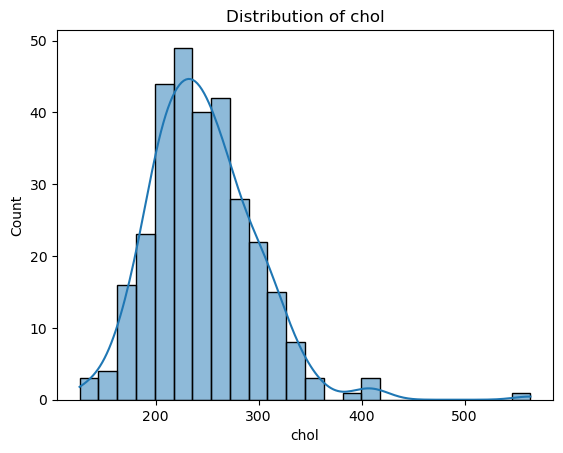

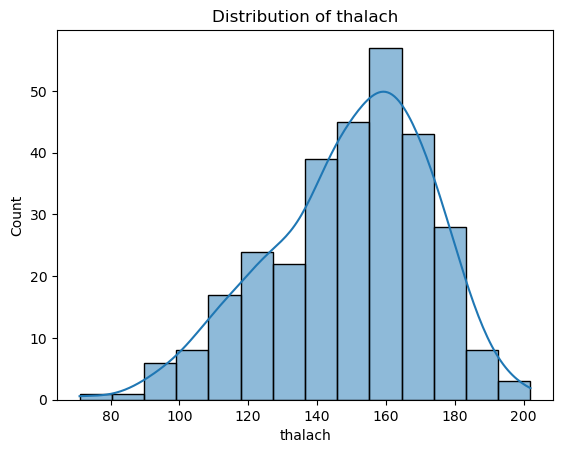

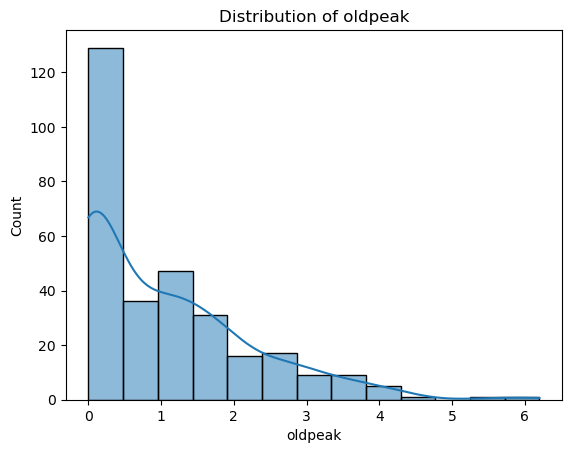

In [406]:
for i in columns:
    sns.histplot(df[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.show()

#### Box Plot Analysis

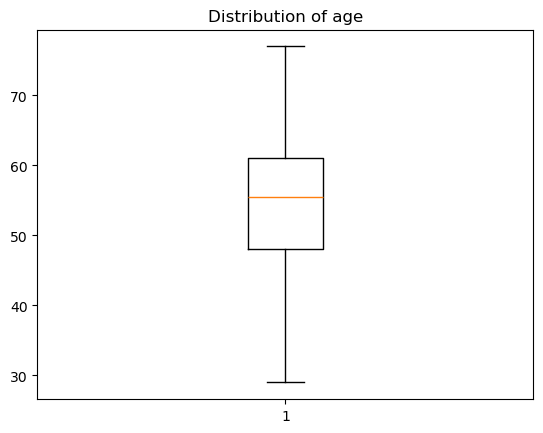

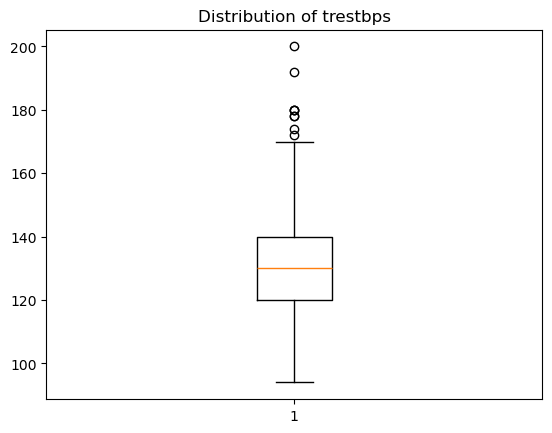

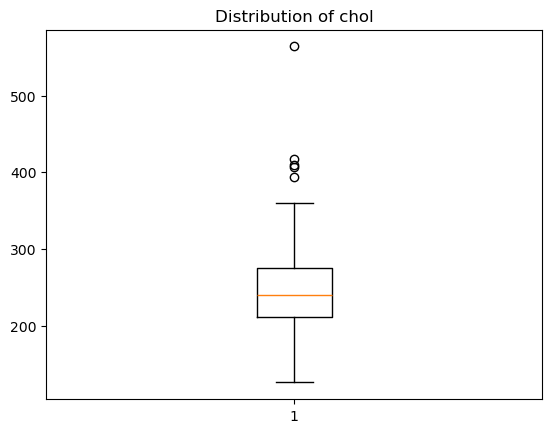

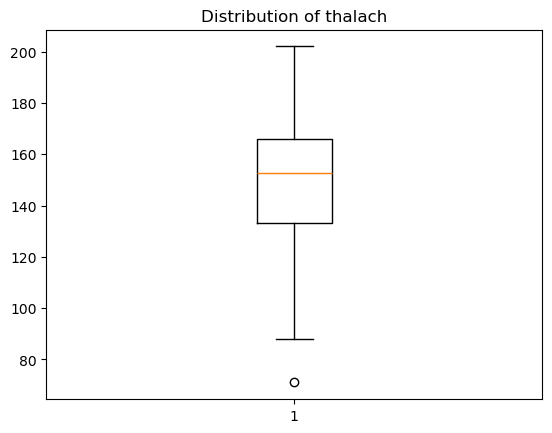

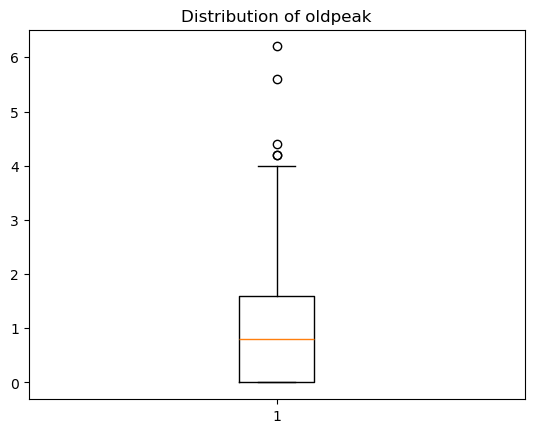

In [407]:
for i in columns:
    plt.boxplot(df[i])
    plt.title(f'Distribution of {i}')
    plt.show()

#### Categorical Feature Analysis

In [408]:
cat_columns = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']

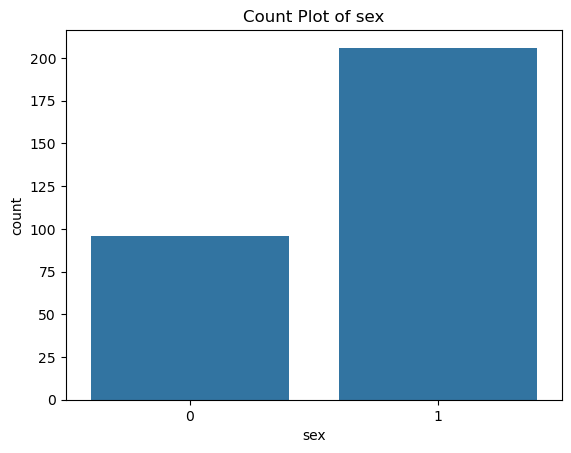

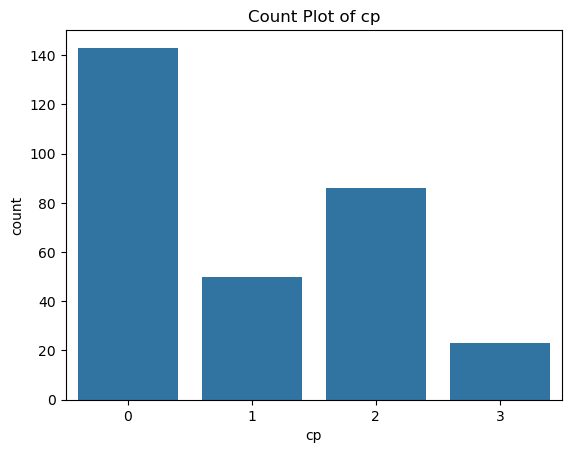

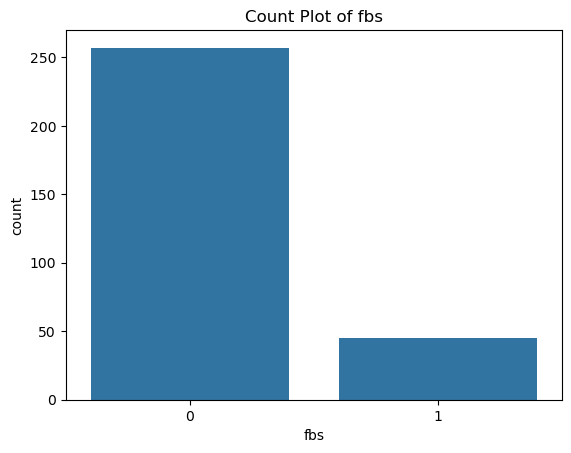

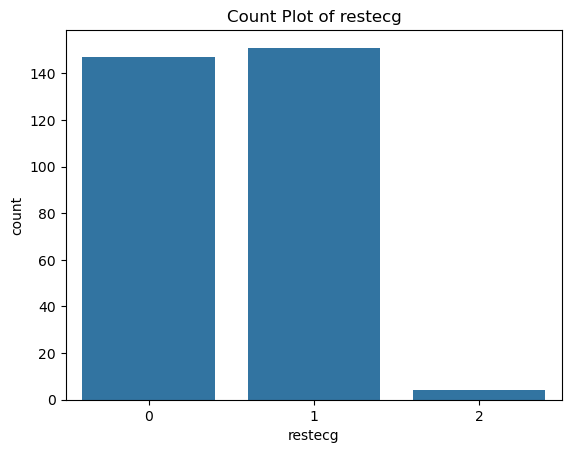

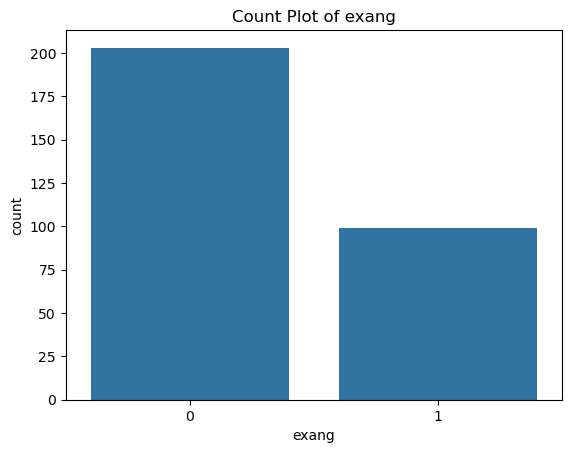

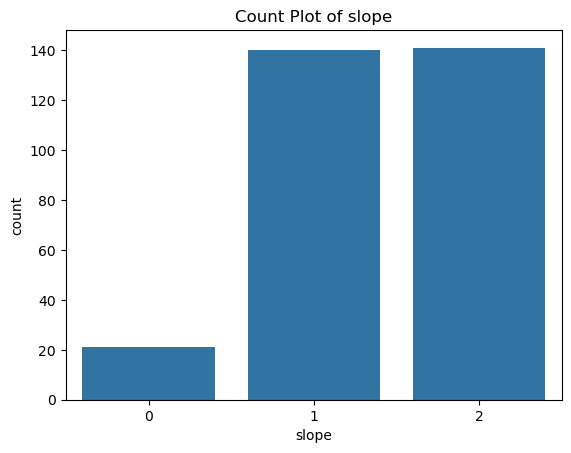

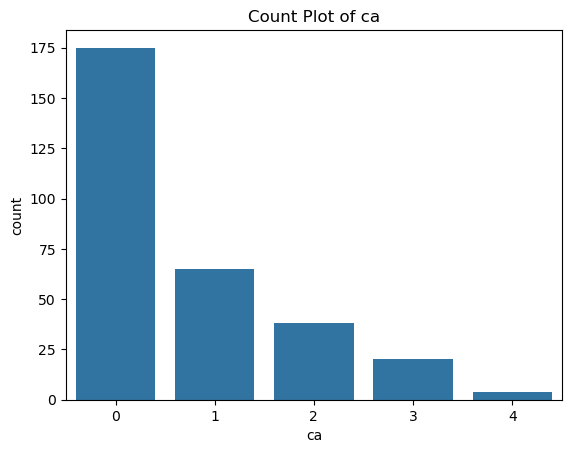

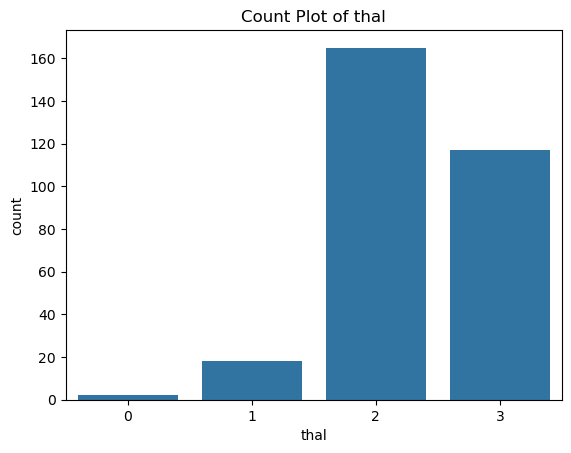

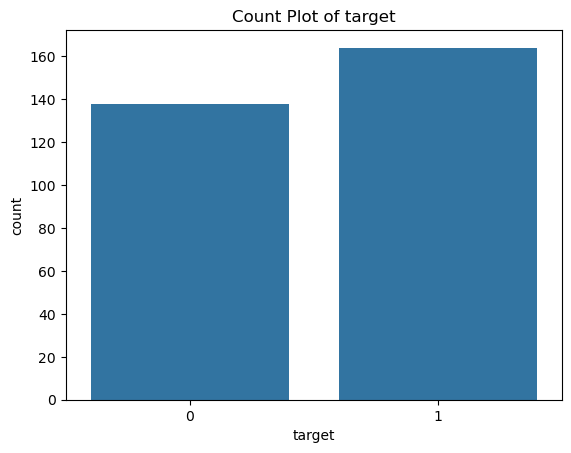

In [409]:
for i in cat_columns:
    sns.countplot(x=i, data=df)
    plt.title(f'Count Plot of {i}')
    plt.show()

#### Correlation Analysis

In [410]:
cor_mat = df.corr(numeric_only=True)

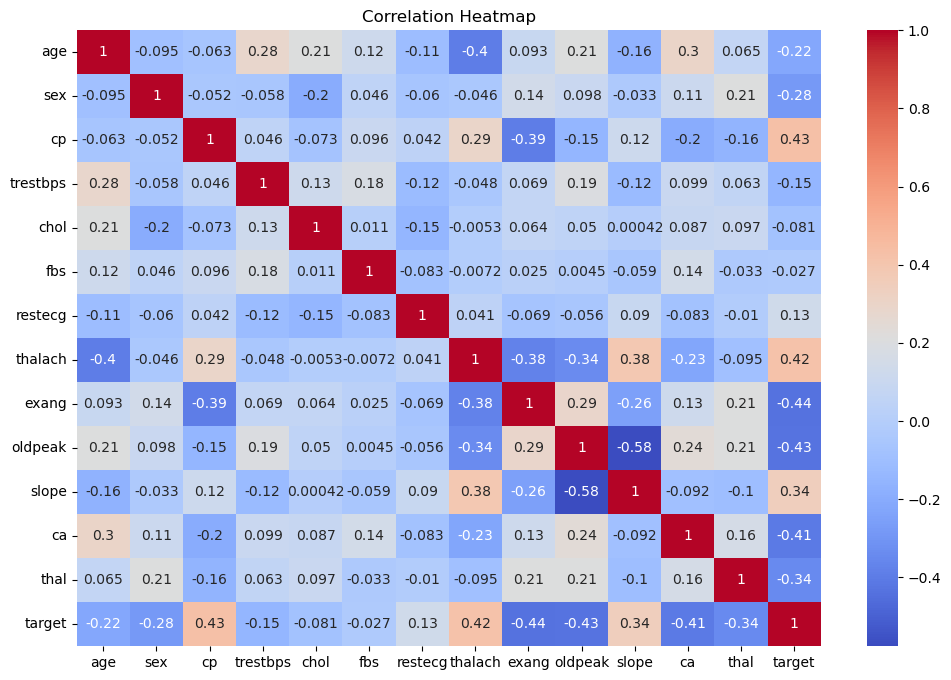

In [411]:
plt.figure(figsize=(12,8))
sns.heatmap(cor_mat,annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

In [412]:
cor_mat['target'].sort_values(ascending=False)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64

In [413]:
cor_mat.loc["slope", "oldpeak"]

np.float64(-0.5763143815309939)

#### Feature vs Target Analysis

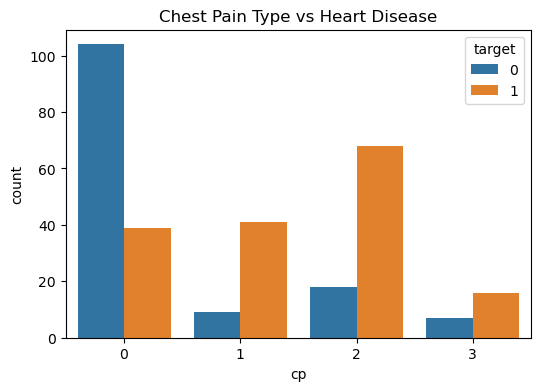

In [414]:
plt.figure(figsize=(6,4))
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

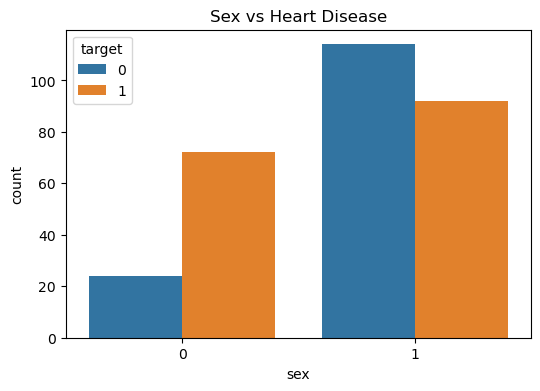

In [415]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='target', data=df)
plt.title("Sex vs Heart Disease")
plt.show()

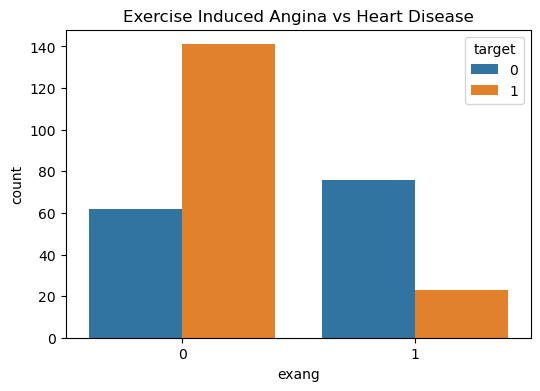

In [416]:
plt.figure(figsize=(6,4))
sns.countplot(x='exang', hue='target', data=df)
plt.title("Exercise Induced Angina vs Heart Disease")
plt.show()

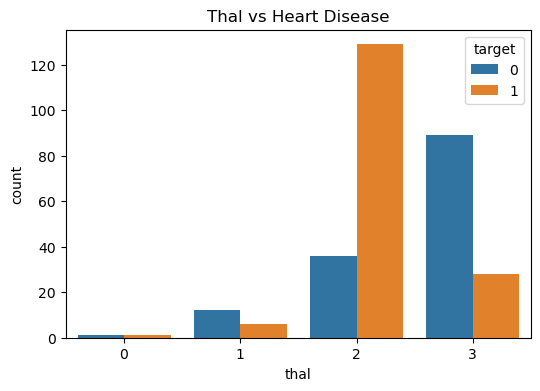

In [417]:
plt.figure(figsize=(6,4))
sns.countplot(x='thal', hue='target', data=df)
plt.title("Thal vs Heart Disease")
plt.show()

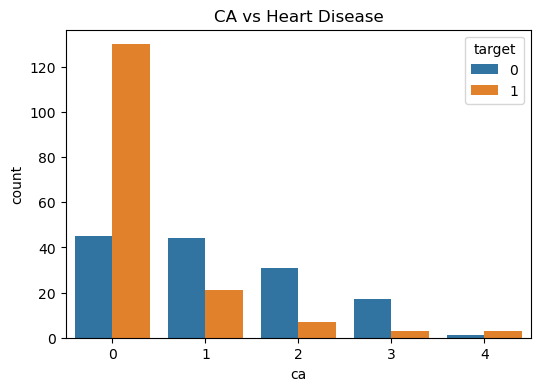

In [418]:
plt.figure(figsize=(6,4))
sns.countplot(x='ca', hue='target', data=df)
plt.title("CA vs Heart Disease")
plt.show()

### Data Preprocessing

#### Define Features and Target

In [419]:
x = df.drop('target', axis=1)
y = df['target']

#### Train-Test Split

In [420]:
x_train, x_test, y_train, y_test = train_test_split(x,y , test_size=0.2, stratify=y, random_state=42)

In [421]:
print('Shape of X_train:',x_train.shape)
print('Shape of X_test:',x_test.shape)
print('\nShape of Y_train:',y_train.shape)
print('Shape of Y_test:',y_test.shape)

Shape of X_train: (241, 13)
Shape of X_test: (61, 13)

Shape of Y_train: (241,)
Shape of Y_test: (61,)


### Scaling

In [422]:
sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

### Model Building

#### Logistic Regression

In [423]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [424]:
y_pred = log_model.predict(x_test_scaled)
y_prob = log_model.predict_proba(x_test_scaled)[:,1]

In [425]:
print('Accuracy Score:', accuracy_score(y_test, y_pred))

Accuracy Score: 0.8032786885245902


In [426]:
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[21  7]
 [ 5 28]]


In [427]:
print(classification_report(y_test, y_pred))
      

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [428]:
print('ROC AUC Score:',roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.8712121212121212


In [429]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

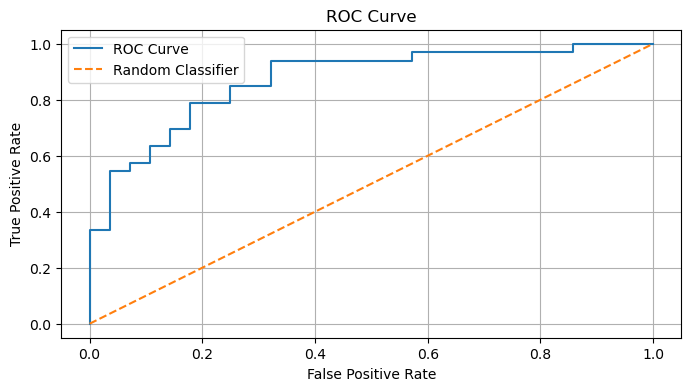

In [430]:
plt.figure(figsize=(8,4))
plt.plot(fpr, tpr, label = 'ROC Curve')
plt.plot([0,1],[0,1], linestyle='--', label = 'Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [431]:
precision, recall, threshold = precision_recall_curve(y_test, y_prob)
average_precision_score(y_test, y_prob)

0.8954410122724028

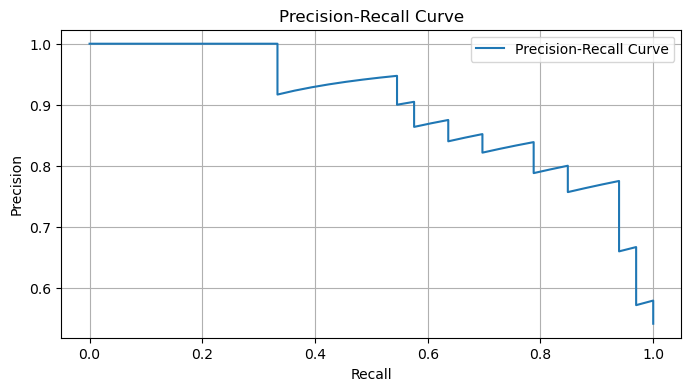

In [432]:
plt.figure(figsize=(8,4))
plt.plot(recall,precision, label = 'Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [433]:
score = cross_val_score(log_model, x,y, cv=5, scoring='roc_auc')

print('score:',score)
print('score mean:',score.mean())

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


score: [0.90151515 0.89069264 0.97879464 0.88888889 0.81257015]
score mean: 0.8944922939714607


In [434]:
param_grid = {'C':[0.01,0.1,1,10,100], 'penalty':['l1', 'l2'], 'solver':['liblinear']}

grid = GridSearchCV(estimator = LogisticRegression(max_iter=5000), param_grid = param_grid, scoring = 'roc_auc', cv= 5, n_jobs=-1)

grid.fit(x_train, y_train)

,estimator,LogisticRegre...max_iter=5000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [435]:
print('Best parameter:',grid.best_params_)
print('Best score:',grid.best_score_)

Best parameter: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best score: 0.9053095053095053


In [436]:
best_model = grid.best_estimator_
print('best estimator:', best_model)

best estimator: LogisticRegression(C=1, max_iter=5000, solver='liblinear')


In [437]:
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]

In [438]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8032786885245902


In [439]:
print(confusion_matrix(y_test,y_pred))

[[21  7]
 [ 5 28]]


In [440]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [441]:
print("ROC-AUC:",roc_auc_score(y_test,y_prob))

ROC-AUC: 0.8668831168831168


#### Decision Tree Classifier

In [442]:
d_model = DecisionTreeClassifier(max_depth=3, random_state=42)
d_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [443]:
y_pred = d_model.predict(x_test)
y_prob = d_model.predict_proba(x_test)[:,1]

In [444]:
print('Accuracy Score:', accuracy_score(y_test, y_pred))

Accuracy Score: 0.8032786885245902


In [445]:
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[20  8]
 [ 4 29]]


In [446]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.78      0.88      0.83        33

    accuracy                           0.80        61
   macro avg       0.81      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



In [447]:
print("Train Accuracy:", d_model.score(x_train, y_train))
print("Test Accuracy :", d_model.score(x_test, y_test))

Train Accuracy: 0.8589211618257261
Test Accuracy : 0.8032786885245902


In [448]:
print('ROC AUC score:', roc_auc_score(y_test, y_prob))

ROC AUC score: 0.8457792207792209


In [449]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

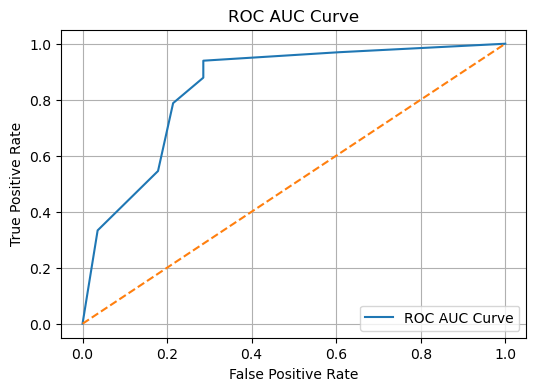

In [450]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='ROC AUC Curve')
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [451]:
precision, recall, threshold = precision_recall_curve(y_test, y_prob)
print('average precision score:', average_precision_score(y_test, y_prob))

average precision score: 0.824143453789111


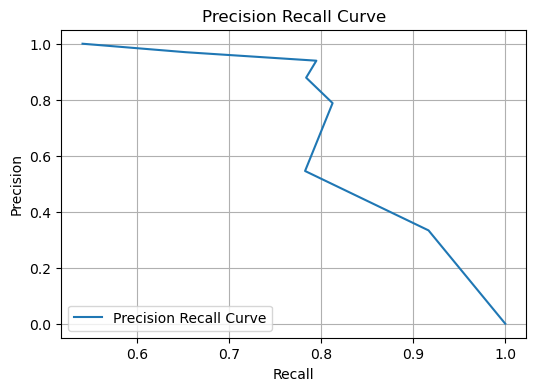

In [452]:
plt.figure(figsize=(6,4))

plt.plot(precision, recall, label='Precision Recall Curve')

plt.xlabel("Recall")
plt.ylabel('Precision')
plt.title('Precision Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [453]:
score = cross_val_score(d_model, x, y , cv=5, scoring='roc_auc')

print('score:',score)
print('score mean:',score.mean())

score: [0.85606061 0.86255411 0.95200893 0.74130191 0.72334456]
score mean: 0.8270540223665221


In [454]:
param_grid = {'criterion':['gini','entropy'], 'max_depth':[3,5,7,10], 'min_samples_split':[2,5,10], 'min_samples_leaf':[1,2,5]}

In [455]:
grid = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid = param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

grid.fit(x_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [456]:
print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best ROC-AUC: 0.8508870758870758


In [457]:
best_model = grid.best_estimator_
print('Best Model:',best_model)

Best Model: DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       min_samples_split=10, random_state=42)


In [458]:
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]

In [459]:
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.7213114754098361


In [460]:
print(confusion_matrix(y_test, y_pred))


[[20  8]
 [ 9 24]]


In [461]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        28
           1       0.75      0.73      0.74        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



In [462]:
print('ROC AUC Score:',roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.8008658008658007


In [463]:
importance = best_model.feature_importances_
importance

array([0.12880547, 0.08503658, 0.34146057, 0.        , 0.03118097,
       0.        , 0.03507831, 0.04522246, 0.05023082, 0.06407742,
       0.        , 0.09447839, 0.12442901])

In [464]:
importance = pd.DataFrame({'Feature':x.columns, 'Importance':best_model.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

print(importance.head(10))

    Feature  Importance
2        cp    0.341461
0       age    0.128805
12     thal    0.124429
11       ca    0.094478
1       sex    0.085037
9   oldpeak    0.064077
8     exang    0.050231
7   thalach    0.045222
6   restecg    0.035078
4      chol    0.031181


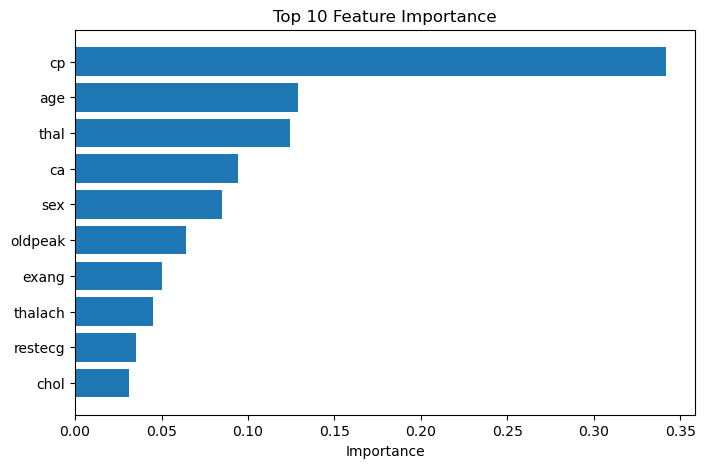

In [465]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance")
plt.show()

#### RandomForest Classifier

In [352]:
rand_model = RandomForestClassifier(random_state=42)
rand_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [353]:
y_pred = rand_model.predict(x_test)

In [354]:
print('Accuracy Score:', accuracy_score(y_test, y_pred))

Accuracy Score: 0.7540983606557377


In [355]:
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[20  8]
 [ 7 26]]


In [356]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



In [357]:
print("Train Accuracy:", rand_model.score(x_train, y_train))
print("Test Accuracy :", rand_model.score(x_test, y_test))

Train Accuracy: 1.0
Test Accuracy : 0.7540983606557377


In [358]:
print('ROC AUC score:', roc_auc_score(y_test, y_prob))

ROC AUC score: 0.8008658008658007


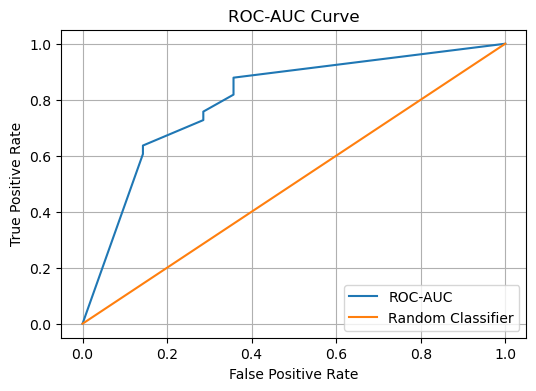

In [359]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='ROC-AUC')
plt.plot([0,1],[0,1], label ='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.grid(True)
plt.show()

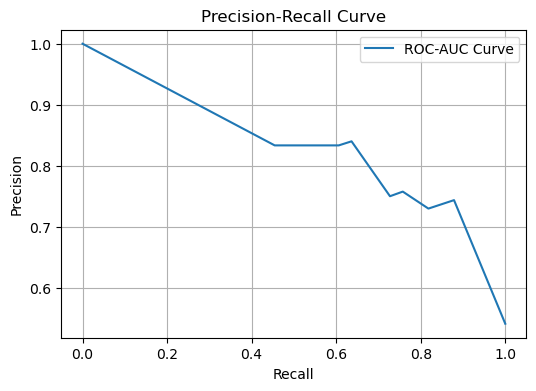

In [360]:
precision, recall, threshold = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label='ROC-AUC Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [361]:
score = cross_val_score(rand_model, x, y, cv=5, scoring='roc_auc')
print('Validation Score:', score)
print('Validation Score Mena:', score.mean())

Validation Score: [0.92316017 0.92099567 0.98158482 0.86868687 0.85858586]
Validation Score Mena: 0.9106026785714285


In [362]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

In [363]:
grid = GridSearchCV(estimator= RandomForestClassifier(random_state=42), param_grid = param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

grid.fit(x_train, y_train)  

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [378]:
print("Best Parameters:",grid.best_params_)

print("Best ROC-AUC:",grid.best_score_)

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best ROC-AUC: 0.9146076146076145


In [379]:
best_model = grid.best_estimator_
best_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [380]:
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]

In [381]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7704918032786885


In [382]:
print(confusion_matrix(y_test, y_pred))

[[21  7]
 [ 7 26]]


In [383]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



In [384]:
print('ROC AUC Score:', roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.8571428571428572


In [385]:
importance = best_model.feature_importances_
importance

array([0.06451952, 0.04480923, 0.19982787, 0.04870779, 0.05690261,
       0.00876426, 0.01449378, 0.13444339, 0.09014344, 0.08855644,
       0.0296906 , 0.11148829, 0.10765279])

In [386]:
importance = pd.DataFrame({'Feature':x.columns, 'Importance':best_model.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

print(importance.head(10))

     Feature  Importance
2         cp    0.199828
7    thalach    0.134443
11        ca    0.111488
12      thal    0.107653
8      exang    0.090143
9    oldpeak    0.088556
0        age    0.064520
4       chol    0.056903
3   trestbps    0.048708
1        sex    0.044809


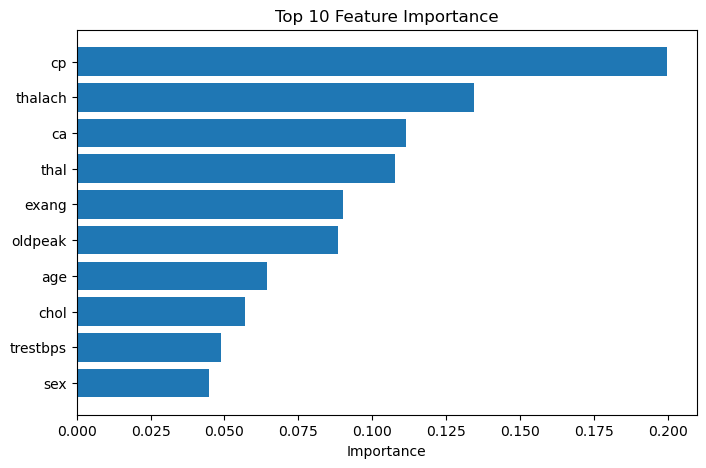

In [387]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance")
plt.show()

### XGBClassifier

In [468]:
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='logloss')
model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [469]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

In [470]:
print('Accuracy:',accuracy_score(y_test, y_pred))

Accuracy: 0.7213114754098361


In [471]:
print('Confusion matrix:', '\n',confusion_matrix(y_test, y_pred))

Confusion matrix: 
 [[20  8]
 [ 9 24]]


In [472]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        28
           1       0.75      0.73      0.74        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



In [473]:
roc_score = roc_auc_score(y_test, y_prob)
print('Roc Auc score:', roc_score)

Roc Auc score: 0.8495670995670996


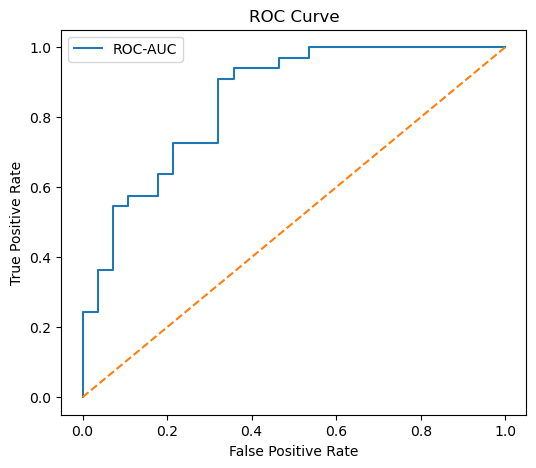

In [474]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC-AUC')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Average Precision: 0.8629888362516938


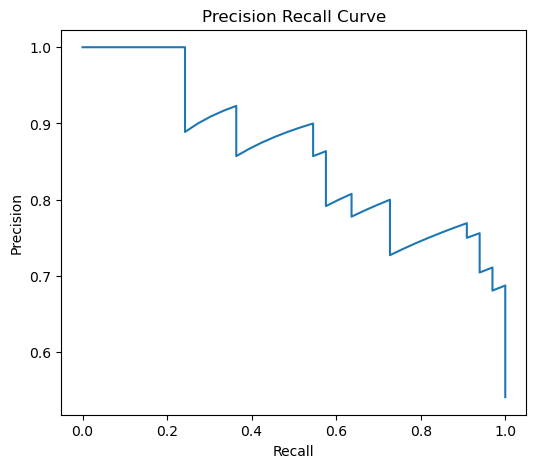

In [475]:
precision, recall, threshold = precision_recall_curve(y_test, y_prob)

ap = average_precision_score(y_test, y_prob)
print("Average Precision:", ap)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

In [476]:
score = cross_val_score(model, x, y, scoring='roc_auc', cv=5)
print('Validation Score:', score)
print('Validation Score Mean:', score.mean())

Validation Score: [0.87121212 0.87662338 0.96875    0.86195286 0.82267116]
Validation Score Mean: 0.8802419031585698


In [477]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [478]:
grid = GridSearchCV(estimator= XGBClassifier(random_state=42), param_grid = param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

grid.fit(x_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [479]:
print("Best Parameters:",grid.best_params_)

print("Best ROC-AUC:",grid.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best ROC-AUC: 0.9095700595700595


In [480]:
best_model = grid.best_estimator_

In [481]:
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]

In [482]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7213114754098361


In [483]:
print(confusion_matrix(y_test, y_pred))

[[20  8]
 [ 9 24]]


In [484]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        28
           1       0.75      0.73      0.74        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



In [485]:
print('ROC AUC Score:', roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.8344155844155844


In [486]:
best_model.feature_importances_

array([0.04594959, 0.06426746, 0.22369596, 0.02721735, 0.03288295,
       0.03346226, 0.04473414, 0.04867774, 0.12518916, 0.04922569,
       0.0543067 , 0.10568363, 0.14470738], dtype=float32)

In [487]:
importance = pd.DataFrame({'Feature':x.columns, 'Importance':model.feature_importances_})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(10))

    Feature  Importance
2        cp    0.253122
12     thal    0.149127
8     exang    0.099328
11       ca    0.098728
1       sex    0.060813
9   oldpeak    0.055604
7   thalach    0.050358
0       age    0.047360
6   restecg    0.046049
10    slope    0.044897


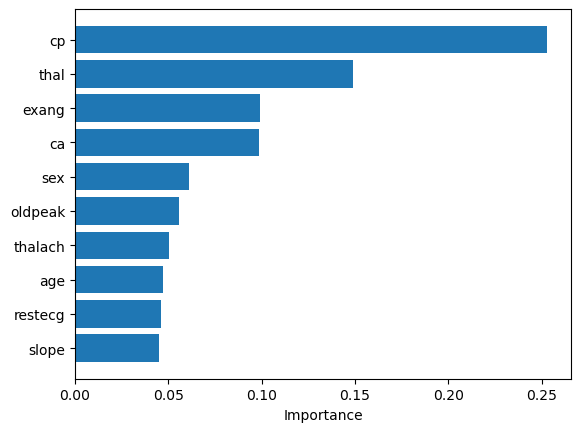

In [488]:
top10 = importance.head(10)

plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()